# Probability Distributions

First, let's import the necessary libraries,

In [182]:
import random, math
import numpy as np
import matplotlib.pyplot as plt

## Continuous Probability Distributions

### Normal Distribution

#### Unimmodal Distribution

Text(0, 0.5, 'Probability Density')

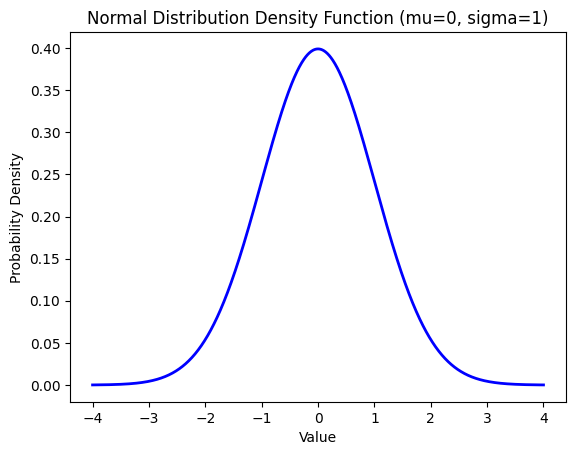

In [183]:
def normal_distribution(x, mu, sigma):
    exponent = math.exp(-((x - mu) ** 2) / (2 * sigma ** 2))
    coefficient = 1 / (sigma * math.sqrt(2 * math.pi))
    return coefficient * exponent

# Plot the density function
x_values = np.linspace(-4, 4, 1000)
density_values = [normal_distribution(x, 0, 1) for x in x_values]

plt.plot(x_values, density_values, color='blue', linewidth=2)
plt.title('Normal Distribution Density Function (mu=0, sigma=1)')
plt.xlabel('Value')
plt.ylabel('Probability Density')

#### Multimodal Distribution

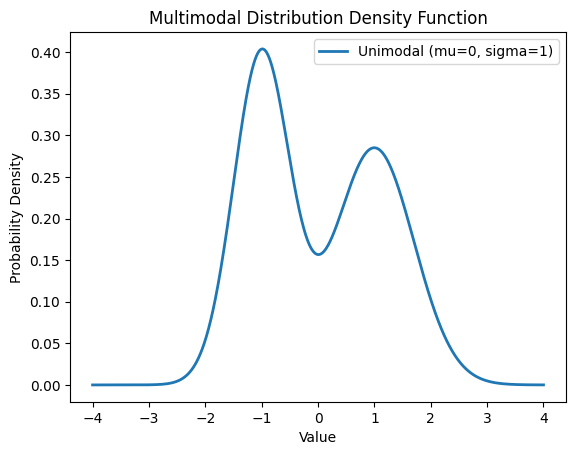

In [184]:
x_values = np.linspace(-4, 4, 1000) 
multimodal_density = [0.5 * normal_distribution(x, -1, 0.5) + 0.5 * normal_distribution(x, 1, 0.7) for x in x_values]

plt.plot(x_values, multimodal_density, linewidth=2)
plt.title('Multimodal Distribution Density Function')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend(['Unimodal (mu=0, sigma=1)', 'Multimodal (mu=-1, sigma=0.5 and mu=1, sigma=0.5)'])

### Exponential Distribution

Text(0, 0.5, 'Probability Density')

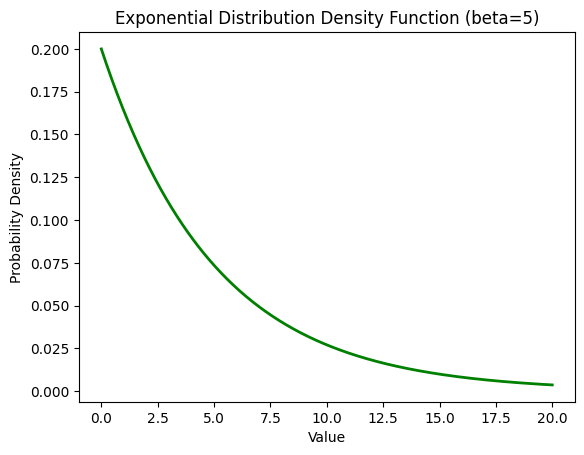

In [185]:
def exponential_distribution(x, beta):
    return (1/beta) * math.exp(-(x/beta)) if x >= 0 else 0

x_values = np.linspace(0, 20, 1000)
density_values = [exponential_distribution(x, 5) for x in x_values]
plt.plot(x_values, density_values, color='green', linewidth=2)
plt.title('Exponential Distribution Density Function (beta=5)')
plt.xlabel('Value')
plt.ylabel('Probability Density')

## Discrete Probability Distributions

### Bernoulli Distribution

In [186]:
def bernoulli(uniform_random, p):
    return 1 if uniform_random < p else 0

bernoulli(random.random(), 0.5)

1

let's plot it,

Text(0, 0.5, 'Relative Frequency')

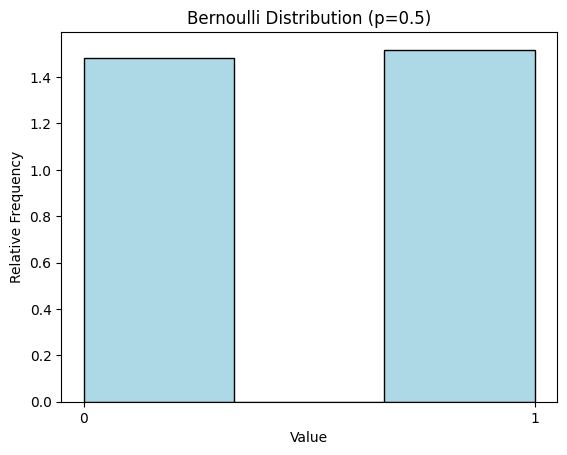

In [187]:
bernoulli_values = [bernoulli(random.random(), 0.5) for _ in range(1000)]

plt.hist(bernoulli_values, bins=3, color='lightblue', edgecolor='black', density=True)
plt.xticks([0, 1])
plt.title('Bernoulli Distribution (p=0.5)')
plt.xlabel('Value')
plt.ylabel('Relative Frequency')

### Binomial Distribution

In [188]:
def binomial(uniform_randoms, p):
    return sum(bernoulli(ur, p) for ur in uniform_randoms)

binomial([random.random() for _ in range(10)], 0.5)

6

Text(0, 0.5, 'Relative Frequency')

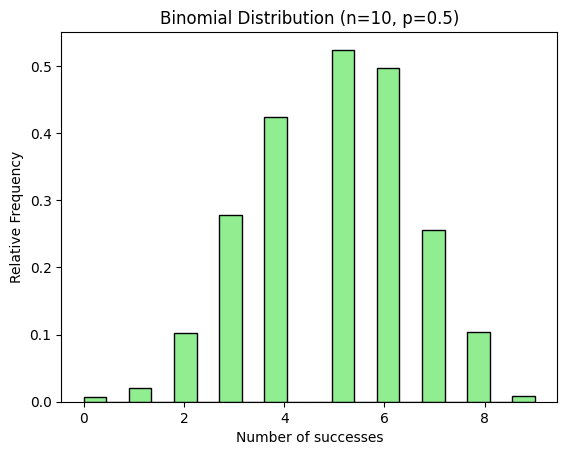

In [189]:
binomial_values = [binomial([random.random() for _ in range(10)], 0.5) for _ in range(1000)]

plt.hist(binomial_values,color='lightgreen', bins=20, edgecolor='black', density=True)
plt.title('Binomial Distribution (n=10, p=0.5)')
plt.xlabel('Number of successes')
plt.ylabel('Relative Frequency')

### Poisson Distribution

#### Mass Function

Text(0, 0.5, 'P(X=x)')

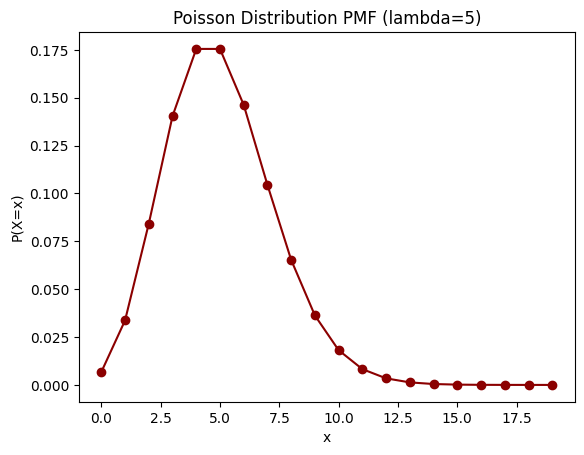

In [190]:
def get_mass(x, lam):
    numerator = math.exp(-lam) * (lam**x)
    denominator = math.factorial(x)
    return numerator / denominator

poisson_values = [get_mass(x, 5) for x in range(0, 20)]
plt.plot(range(0, 20), poisson_values, marker='o', linestyle='-', color='darkred')
plt.title('Poisson Distribution PMF (lambda=5)')
plt.xlabel('x')
plt.ylabel('P(X=x)')

#### Simulation

In [191]:
def simulate_poisson(lam):
    u = random.random() 
    x = 0
    running_total = get_mass(0, lam) 
    
    while u > running_total:
        x += 1
        running_total += get_mass(x, lam)
        
    return x 

Text(0, 0.5, 'Relative Frequency')

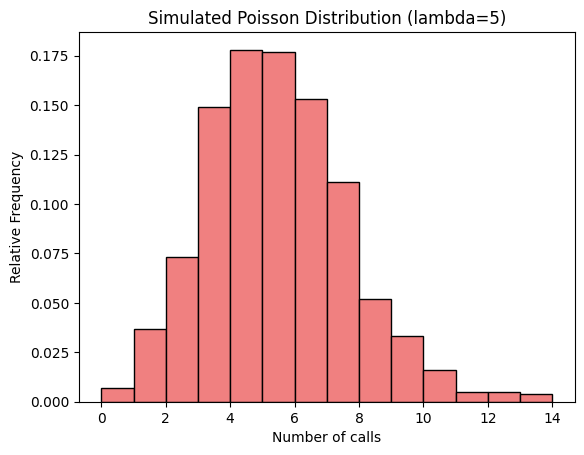

In [192]:
poisson_samples = [simulate_poisson(5) for _ in range(1000)]
plt.hist(poisson_samples, bins=range(0, max(poisson_samples)+1), color='lightcoral', edgecolor='black', density=True)
plt.title('Simulated Poisson Distribution (lambda=5)')
plt.xlabel('Number of calls')
plt.ylabel('Relative Frequency')